In [1]:
import pandas as pd
import numpy as np
import parselmouth
from parselmouth.praat import call
import os
from pyrpde import  rpde
import nolds
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.pyplot as plt
from scipy.io import wavfile
import noisereduce as nr
from pathlib import Path
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import random

In [2]:
def load_audio_files(directory):
    audio_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".wav"):
            audio_files.append(os.path.join(directory, filename))
    return audio_files

In [3]:
def denoise(audio_files): # Takes a list of audio files
    path = Path(audio_files[0]).resolve()
    original_folder = path.parent
    
    new_folder_name = f"{original_folder.name}_noise_reduce"
    output_dir = original_folder.parent / new_folder_name
    output_dir.mkdir(parents=True, exist_ok=True)

    for audio_file in tqdm(audio_files, desc='Denoising Audio'):
        try:
            path = Path(audio_file).resolve()
            rate, data = wavfile.read(path)
            reduced_noise = nr.reduce_noise(y=data, sr=rate)
        
            file_name = path.name
            output_path = output_dir / f"reduced_{file_name}"    
            wavfile.write(output_path, rate, reduced_noise)
        except:
            print(f"Error processing {audio_file}")

    return output_dir

In [4]:
def extract_features(audio_file):
    sound = parselmouth.Sound(audio_file)
    sound.scale_peak(10)
    pitch = sound.to_pitch()
    intensity = sound.to_intensity()

    pitch_mean = call(pitch, "Get mean", 0, 0, "Hertz")      # MDVP:Fo
    pitch_min = call(pitch, "Get minimum", 0, 0, "Hertz", "Parabolic") # MDVP:Flo
    pitch_max = call(pitch, "Get maximum", 0, 0, "Hertz", "Parabolic") # MDVP:Fhi
    longest_period = 1 / (pitch_min * 0.9)
    # intensity_mean = intensity.get_mean() 

    point_process = call(sound, "To PointProcess (periodic, cc)", pitch_min, pitch_max)
    
    local_jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:Jitter(%)
    mdvp_jitter_percent = local_jitter
    mdvp_jitter_abs = call(point_process, "Get jitter (local, absolute)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:Jitter(Abs)
    mdvp_rap = call(point_process, "Get jitter (rap)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:RAP
    jitter_ppq = call(point_process, "Get jitter (ppq5)", 0, 0, 0.0001, longest_period, 1.3) # Jitter:ppq
    jitter_ddp = call(point_process, "Get jitter (ddp)", 0, 0, 0.0001, longest_period, 1.3) # Jitter:dpq

    mdvp_shimmer = call([sound, point_process], "Get shimmer (local)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # MDVP:Shimmer
    mdvp_shimmer_db = call([sound, point_process], "Get shimmer (local_dB)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # MDVP:Shimmer(dB)    
    shimmer_apq3 = call([sound, point_process], "Get shimmer (apq3)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ3
    shimmer_apq5 = call([sound, point_process], "Get shimmer (apq5)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ5
    shimmer_apq = call([sound, point_process], "Get shimmer (apq11)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ
    shimmer_dda = call([sound, point_process], "Get shimmer (dda)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:DDA


    harmonicity_obj = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr = call(harmonicity_obj, "Get mean", 0, 0)

    data = sound.values.flatten()
    max_val = np.max(np.abs(data))
    if max_val > 0:
        data = (data / max_val) * 0.99 
    data = data.astype(np.float32)
    ent, histogram = rpde(data, tau=30, dim=3, epsilon=0.01, tmax=1500) 
    RPDE = ent.item() # RPDE
    
    pitch_values = pitch.selected_array['frequency']
    pitch_nonzero = pitch_values[pitch_values > 0]
    
    if len(pitch_nonzero) > 20:
        dfa_alpha = nolds.dfa(pitch_nonzero)
    else:
        dfa_alpha = np.nan

    # Extract pitch values (in Hz)
    pitch_values = pitch.selected_array['frequency']
    # Filter out unvoiced frames
    pitch_values = pitch_values[pitch_values > 0]
    
    # Convert to semitones (optional, but standard for PPE)
    semitones = 12 * np.log2(pitch_values / 110.0)
    
    # Calculate Probability Distribution
    value_counts, bin_edges = np.histogram(semitones, bins='auto', density=True)
    probabilities = value_counts / value_counts.sum()
    
    # Calculate Shannon Entropy
    ppe = entropy(probabilities)

    return {
        "MDVP:Jitter(%)": mdvp_jitter_percent,
        "MDVP:Jitter(Abs)": mdvp_jitter_abs,
        "MDVP:RAP": mdvp_rap,
        "Jitter:ppq": jitter_ppq,
        "Jitter:dpq": jitter_ddp,
        "MDVP:Shimmer": mdvp_shimmer,
        "MDVP:Shimmer(dB)": mdvp_shimmer_db,
        "Shimmer:APQ3": shimmer_apq3,
        "Shimmer:APQ5": shimmer_apq5,
        "MDVP:APQ": shimmer_apq,
        "Shimmer:DDA": shimmer_dda
        # "NHR": nhr,
        # "HNR": hnr,
        # "RPDE": RPDE,
        # "DFA": dfa_alpha,
        # "PPE": ppe
        # "D2": d2,
        
        # "pitch_mean": pitch_mean,
        # "pitch_min": pitch_min,
        # "pitch_max": pitch_max,
    }

directory = "pd_dataset/HC_AH"
audio_files = load_audio_files(directory)
directory = denoise(audio_files) # Get directory of noise_reduced audio files


audio_files = load_audio_files(directory)
feature_list = []
for audio_file in tqdm(audio_files[0:5]):
    features = extract_features(audio_file)
    feature_list.append(features)
    
HC = pd.DataFrame(feature_list)
HC['Target'] = 0
display(HC)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.59it/s]


,MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,Jitter:ppq,Jitter:dpq,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,Target
0,0.004361,0.000033,0.002167,0.002332,0.006502,0.060940,0.569152,0.026971,0.033558,0.052095,0.080914,0
1,0.006447,0.000058,0.003274,0.003979,0.009821,0.108743,0.984862,0.047514,0.058797,0.089296,0.142543,0
2,0.004375,0.000019,0.002535,0.002644,0.007605,0.085657,0.674648,0.037634,0.050009,0.074012,0.112903,0
3,0.004651,0.000045,0.002574,0.002511,0.007721,0.103280,0.930780,0.044919,0.046599,0.072290,0.134758,0
4,0.005268,0.000047,0.002564,0.003286,0.007691,0.095900,0.966003,0.046636,0.059112,0.102808,0.139908,0


In [5]:
# sound = parselmouth.Sound(audio_files[0])
# sound.get_maximum()
# sound.scale_intensity(50)
# sound.get_maximum()
# pitch = sound.to_pitch()
# intensity = sound.to_intensity()


| Feature          | Description                                                                                                    |   |   |
|------------------|----------------------------------------------------------------------------------------------------------------|---|---|
| MDVP:Jitter(%)   | [Kay Pentax MDVP jitter as a percentage](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:Jitter(Abs) | [Kay Pentax MDVP absolute jitter in microseconds](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:RAP         | [Kay Pentax MDVP Relative Amplitude Perturbation](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:PPQ         | [Kay Pentax MDVP five-point Period Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Jitter:DDP       | [Average absolute difference of differences between cycles, divided by the average period](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                      |   |   |
| MDVP:Shimmer     | [Kay Pentax MDVP local shimmer](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:Shimmer(dB) | [Kay Pentax MDVP local shimmer in decibels](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:APQ3     | [Three point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:APQ5     | [Five point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:APQ         | [Kay Pentax MDVP 11-point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:DDA      | [Average absolute difference between consecutive differences between the amplitudes of consecutive periods](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                      |   |   |
| NHR              | [Noise-to-Harmonics Ratio](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| HNR              | [Harmonics-to-Noise Ratio](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| RPDE             | [Recurrence Period Density Entropy](https://pmc.ncbi.nlm.nih.gov/articles/PMC1913514/)                     |   |   |
| DFA              | [Detrended Fluctuation Analysis](https://pmc.ncbi.nlm.nih.gov/articles/PMC1913514/)                        |   |   |
| D2               | Correlation dimension                                                                                      |   |   |
| PPE              | [Pitch period entropy](https://pmc.ncbi.nlm.nih.gov/articles/PMC3051371/#R23)                              |   |   |

In [6]:
directory = "pd_dataset/HC_AH"
audio_files = load_audio_files(directory)
# directory = denoise(audio_files) # Get directory of noise_reduced audio files

audio_files = load_audio_files(directory)
feature_list = []
for audio_file in tqdm(audio_files):
    features = extract_features(audio_file)
    feature_list.append(features)
    
HC = pd.DataFrame(feature_list)
HC['target'] = 0
# display(HC)

 

directory = "pd_dataset/PD_AH"
audio_files = load_audio_files(directory)
# directory = denoise(audio_files) # Get directory of noise_reduced audio files

audio_files = load_audio_files(directory)
feature_list = []
for audio_file in tqdm(audio_files):
    features = extract_features(audio_file)
    feature_list.append(features)
    
PD = pd.DataFrame(feature_list)
PD['target'] = 1
# display(PD)

df = pd.concat([PD, HC])
df

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:40<00:00,  1.02s/it]


,MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,Jitter:ppq,Jitter:dpq,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,target
0,0.006887,0.000055,0.003938,0.003574,0.011815,0.064868,0.571932,0.034361,0.042745,0.057396,0.103084,1
1,0.005290,0.000048,0.002768,0.003333,0.008303,0.092533,0.828010,0.048483,0.062845,0.081784,0.145450,1
2,0.004651,0.000020,0.002386,0.002885,0.007159,0.068015,0.520065,0.032231,0.039134,0.043309,0.096692,1
3,0.010641,0.000040,0.005679,0.006290,0.017037,0.059716,0.686048,0.031052,0.040576,0.054637,0.093156,1
4,0.004003,0.000025,0.002125,0.002551,0.006374,0.054250,0.534961,0.024562,0.034586,0.056537,0.073686,1
...,...,...,...,...,...,...,...,...,...,...,...,...
36,0.003963,0.000021,0.002278,0.002254,0.006835,0.032096,0.279673,0.015192,0.022238,0.029767,0.045575,0
37,0.007905,0.000044,0.004669,0.004903,0.014007,0.073395,0.652117,0.041402,0.047045,0.052441,0.124206,0
38,0.009772,0.000117,0.004798,0.006365,0.014395,0.110403,0.975385,0.057743,0.078995,0.101562,0.173230,0
39,0.003894,0.000016,0.002258,0.002430,0.006774,0.042080,0.396769,0.022195,0.028328,0.040041,0.066585,0


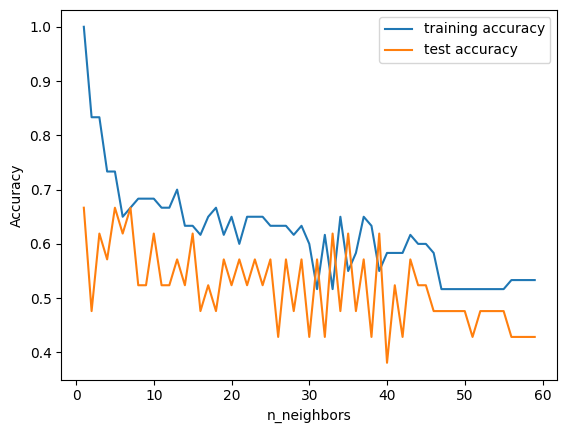

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(df.drop(['target'], axis=1),df['target'],
                                                    test_size=0.25,random_state=42)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 60) # try n_neighbors from 1 to 50

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
    clf.fit(X_train, y_train)

    training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
    test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

pass

In [8]:
lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()
for seedN in tqdm(range(1, 50, 1)):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df.drop(['target'], axis=1),df['target'],
                                                    test_size=0.25,random_state=seedN)

    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50) # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

    lahat_training[seedN] = training_accuracy
    lahat_test[seedN] = test_accuracy

100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [00:47<00:00,  1.04it/s]


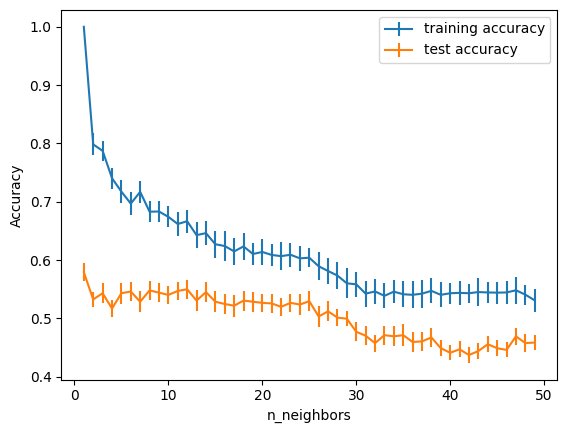

In [9]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [10]:
'''Logistic regression with scaling for reproducibility''' 

X = df.select_dtypes(include=['number']).drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict
predictions = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.48


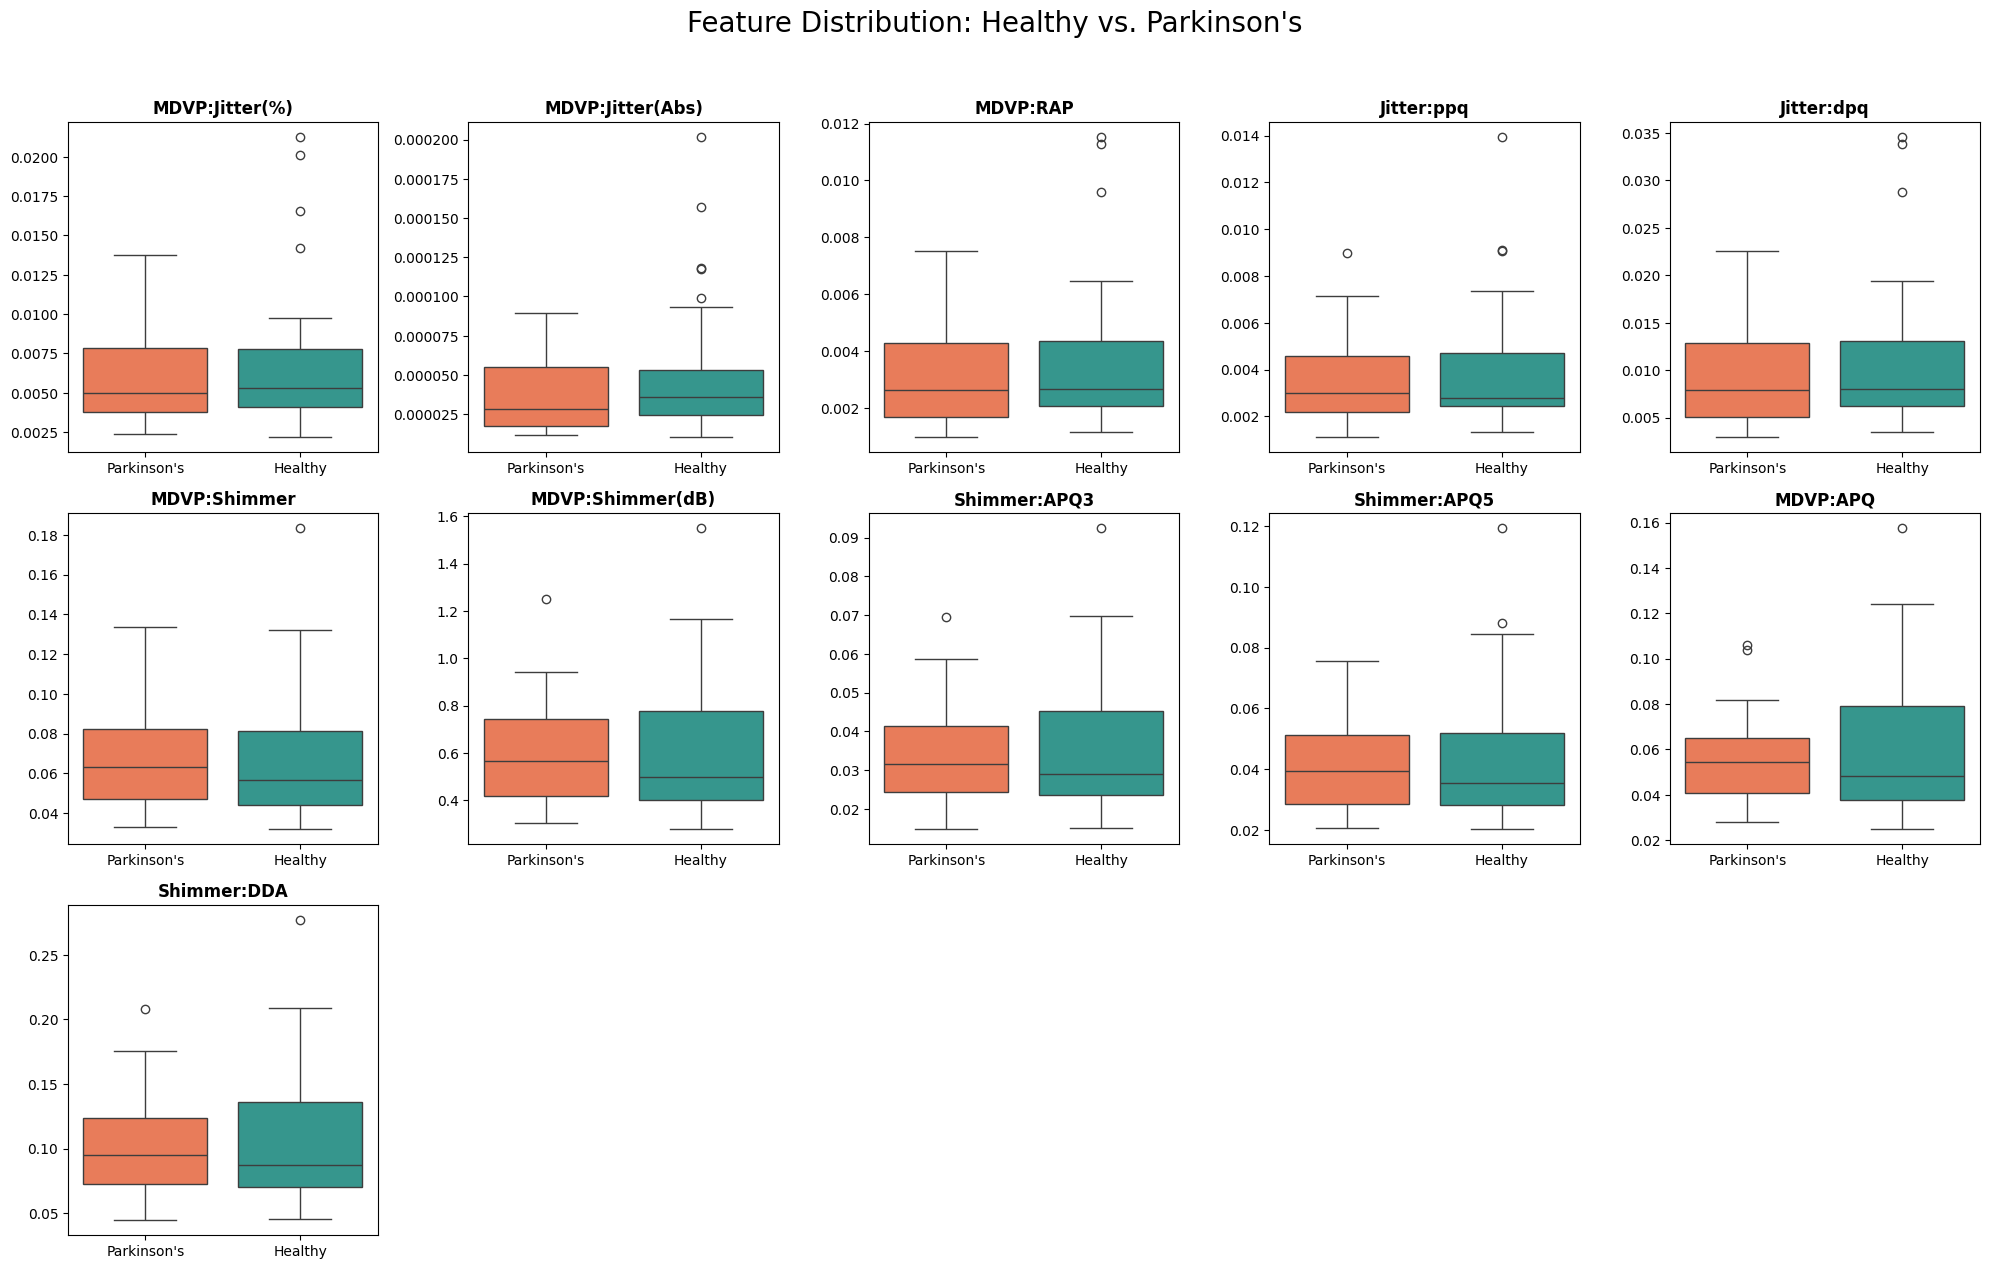

In [11]:
'''Code for EDA'''

# Convert labels for the legend/axis
df["target_label"] = df["target"].map({0: "Healthy", 1: "Parkinson's"})

# Get all features except the target 
feature_cols = [col for col in df.columns if col not in ['target', 'target_label']]

plt.figure(figsize=(20, 16))

# Define a color palette 
palette = { "Healthy": "#26a69a", "Parkinson's": "#ff7043" }

# Set up the graph format 
for i, feature in enumerate(feature_cols):
    plt.subplot(4, 5, i + 1)

    # plot 
    
    sns.boxplot(
        x="target_label", 
        y=feature, 
        data=df,
        palette=palette,
        hue="target_label", 
        legend=False
    )
    
    plt.title(feature, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distribution: Healthy vs. Parkinson's", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()